# Prometheus demo

In this notebook we will:

- Load in the NANOGrav 15-year data set and create a Prometheus `data` object

- Build pulsar noise models, a GWB model, and a deterministic signal model

- Sample the joint model using NUTS from `NumPyro`.

The Prometheus objects are structured as
<img src="prometheus.png" alt="prometheus_flow" width="1000" height="300"/>

In [1]:
# if needed
# !pip install corner
# !pip install ...

In [2]:
# to load/save objects
import json
import pickle
from enterprise_extensions.load_feathers import load_feathers_from_folder

# for plotting
import numpy as np
import matplotlib.pyplot as plt
import corner

# for sampling
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro

import prometheus

libstempo not installed. PINT or libstempo are required to use par and tim files.
PINT not installed. PINT or libstempo are required to use par and tim files.


In [3]:
# IMPORTANT: make sure we're running JAX on GPU
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


## Load data

In [4]:
# load feather pulsar objects
psrs = load_feathers_from_folder('NG15_data/feathers')

# load white noise dictionary
with open('NG15_data/15yr_wn_dict.json', 'r') as fp:
    wn_dict = json.load(fp)

FeatherPulsar.read_feather: cannot find fitpars in feather file NG15_data/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file NG15_data/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file NG15_data/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file NG15_data/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file NG15_data/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file NG15_data/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file NG15_data/feathers/v1p1_de440_pint_bipm2019-J0610-2100.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file NG15_data/feathers/v1p1_de440_pint_bipm201

In [5]:
from prometheus import data

# now we can construct the prometheus.data.Data object
NG15_data = data.Data(name='NG15',
                      psrs=psrs,
                      wn_dict=wn_dict,
                      nfreqs=30,
                      nfreqs_det=120)

# save the data object for future analyses/models
NG15_data.save_data(filepath='NG15_data/data.pkl')

building pulsar models: 100%|██████████| 67/67 [01:42<00:00,  1.53s/it, running J0437-4715]


Saved data object to NG15_data/data.pkl.


In [6]:
# or load a previously constructed data object
# with open('NG15_data/data.pkl', 'rb') as fp:
#     NG15_data = pickle.load(fp)

In [7]:
print(f'number of pulsars in array = {NG15_data.npsrs}')
print(f'total observation span [s] = {NG15_data.Tspan}')
print(f'some pulsar names = {NG15_data.psr_names[:3]}')
print(f'some pulsar positions = {NG15_data.psrpos[:3]}')

number of pulsars in array = 67
total observation span [s] = 505861299.1401644
some pulsar names = ['J1312+0051', 'J0613-0200', 'J0610-2100']
some pulsar positions = [[-0.94989854 -0.31220612  0.01483489]
 [-0.05984838  0.9975892  -0.03512833]
 [-0.04164258  0.932603   -0.35849348]]


In [8]:
print(dir(NG15_data))

['FNFs', 'FNrs', 'Nsparse', 'Si0_a_hat_j', 'Si0_a_hat_j_pf', 'Sigma_0_inv_j', 'Sigma_0_inv_jc', 'Sigma_0_logdet_j', 'TDNTDs', 'TDNrs', 'TNTDs', 'Tspan', 'Tspan_ext', 'Tukey_det', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', 'a_hat_2d_pf', 'a_hat_j', 'det_window_ext_factor', 'ecorr', 'freqs', 'freqs_forFFT', 'ii_diag_fp', 'ii_diag_pf', 'name', 'ncomponents', 'nfreqs', 'nfreqs_det', 'npsrs', 'num_coeff_det', 'per_psr_data_dict', 'phiinv_0_cube_fp', 'phiinv_0_cube_pf', 'phiinv_0_j', 'phiinv_0_vecs_j', 'phiinv_logdet_0_j', 'psr_dist_method', 'psr_dists_dict', 'psr_dists_measured', 'psr_dists_std', 'psr_names', 'psr_phi', 'psr_theta', 'psrpos', 'psrs', 'save_data', 'sparse_toas_de

## Build pulsar noise model

In [9]:
from prometheus.spectral_models import IndependentSpectralModel
from prometheus import spectra

# this gets applied to every pulsar independently
psr_model = IndependentSpectralModel(name='psr_params',
                                     get_phi_diag_func=spectra.free_spectral,
                                     parameter_bounds=[[-20., -7.]]*NG15_data.nfreqs,  # min/max log10_power [s^2] per freq
                                     data=NG15_data)

### What is this `get_phi_diag_func`?

Technically, this function parameterizes the diagonal elements of the prior covariance matrix on the Fourier coefficients:

\begin{equation*}
    p(\mathbf{a}|\boldsymbol{\eta}) = \frac{1}{\sqrt{\text{det}(2\pi\boldsymbol{\phi})}}\,\text{exp}\bigg[-\frac{1}{2}\mathbf{a}^\text{T}\,\boldsymbol{\phi}^{-1}\,\mathbf{a}\bigg]
\end{equation*}
where $\text{diag}\,\boldsymbol{\phi} = \text{diag}\,\boldsymbol{\phi}(\boldsymbol{\eta})$. For example a power law spectral model is

\begin{equation*}
    \text{diag}\,\boldsymbol{\phi}(A, \gamma, f) = \frac{A^2}{12\pi^2}\frac{1}{T}\bigg(\frac{f}{1\,\text{yr}^{-1}}\bigg)^{-\gamma}\;\text{yr}^2\,.
\end{equation*}

**Important**:
- function should be written in JAX
- stable in single precision (`float32`)
- outputs covariance elements in $\text{nano-seconds}^2$.

## Build GWB model

In [10]:
from prometheus.spectral_models import CommonSpectralModel

gwb_model = CommonSpectralModel(name='gwb_params',
                                get_phi_diag_func=spectra.power_law,
                                parameter_bounds=[[-20., -10.], # log10_amp bounds
                                                  [0., 7.]],    # spectral index bounds
                                data=NG15_data,
                                correlation_matrix='HD',  # or 'CURN' or any (Np, Np) correlation matrix,
                                nfreqs=14)

## Build deterministic model

A CW from an individual supermassive black hole binary, with evolution and Earth & pulsar terms, see Ellis et. al 2012, 2013.

The parameters of this CW model are: 

\begin{equation*}
\bigg\{\log_{10}(\mathcal{M}\,\,[M_\odot]), \;\log_{10}(f_{CW}\,\,[\text{Hz}]), \;\cos{\iota},\; \psi, \;\log_{10} h,\; \cos{\theta}, \;\phi, \;\Phi_0\bigg\}
\end{equation*}

That is, chirp mass, frequency, inclination, polarization, amplitude, polar sky location, azimuthal sky location, and initial phase, respectively.

There are additional pulsar phase and distance parameters (one phase and distance for every pulsar).

In [11]:
# the minimum/maximum values of the source parameters in the order above
# the pulsar phase and distance parameters are sampled automatically
cw_source_mins = np.array([7.2, -8.7, -1., 0, -18., -1., 0., 0.])
cw_source_maxs = np.array([10., -8.2, 1., np.pi, -12., 1., 2. * np.pi, 2. * np.pi])
cw_parameter_bounds = np.array([cw_source_mins, cw_source_maxs]).T

In [12]:
from prometheus.deterministic_models import DeterministicModel
from prometheus.deterministic import cw_delay_evolve_low_freq_float32

cw_model = DeterministicModel(name='cw_params',
                              data=NG15_data,
                              get_delays_func=cw_delay_evolve_low_freq_float32,
                              parameter_bounds=cw_parameter_bounds,
                              with_psr_params=True)

### What is this `get_delays_func`?

This is a function which takes TOAs, pulsar positions, and deterministic model parameters as input. It outputs the induced deterministic timing delays in every pulsar over the TOAs.

**Important**:
- function should be batched over pulsars
- written in JAX
- stable in single precision (`float32`)
- outputs timing delays in nano-seconds.

## Build a PTA model

In [13]:
from prometheus.pta_model import PTAModel
pta_model = PTAModel(psr_model=psr_model,
                     gwb_model=gwb_model,
                     det_model=cw_model)

## Sample!

We're done with Prometheus. This is NumPyro code.

In [14]:
# build the NumPyro NUTS kernel
nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model)

# specify MCMC attributes
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000)

# random seed to start sampler
# if step size < 1e-5, change this!
seed = 200129

# run MCMC and get samples
mcmc.run(jr.PRNGKey(seed))
samples = mcmc.get_samples()

warmup:   0%|          | 9/6000 [00:13<2:08:25,  1.29s/it, 1023 steps of size 8.12e-03. acc. prob=0.55]

sample: 100%|██████████| 6000/6000 [09:47<00:00, 10.22it/s, 63 steps of size 5.35e-02. acc. prob=0.79]  


In [15]:
from prometheus import utilities as utils

# save our samples
utils.save_chain(samples_dict=samples,
                 filepath='chains/NG15_demo_model.feather',
                 save_coeff_samples=False)

# or load samples from previous run
# samples = utils.load_chain(filepath='chains/NG15_demo_model.feather')

Saved chain samples to chains/NG15_demo_model.feather.


## Plotting

The NumPyro samples (`mcmc.get_samples()`) are stored in a dictionary.

In [16]:
# get samples for constituent models
gwb_samples = np.array(samples[gwb_model.name])
psr_samples = np.array(samples[psr_model.name])
cw_samples = np.array(samples[cw_model.name])

print(gwb_samples.shape)
print(psr_samples.shape)
print(cw_samples.shape)

(5000, 2)
(5000, 67, 30)
(5000, 8)


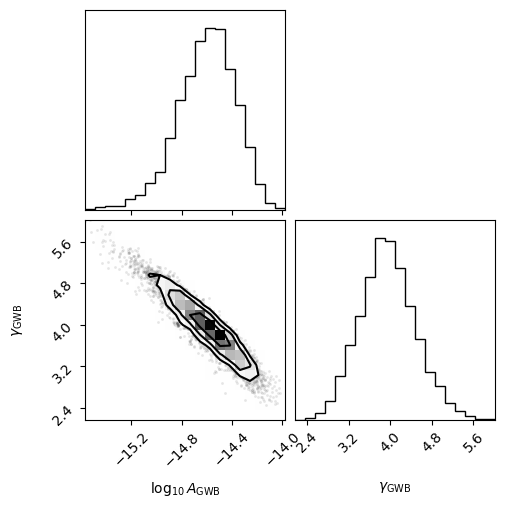

In [17]:
# show recovery of GWB
fig = corner.corner(data=gwb_samples,
                    labels=[r'$\log_{10}A_\text{GWB}$',
                            r'$\gamma_\text{GWB}$'])

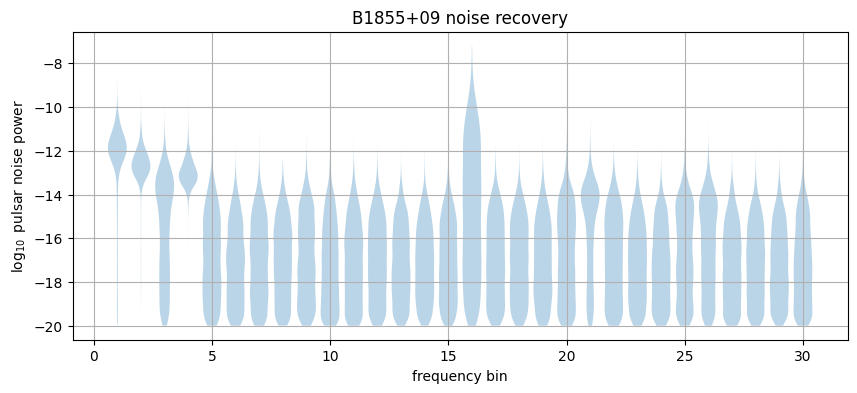

In [18]:
# which pulsar to show noise recovery
psr_ndx = 16

# violin plot for free spectral recovery
plt.figure(figsize=(10, 4))
plt.violinplot(dataset=psr_samples[:, psr_ndx],
               showextrema=False,
               widths=0.8)
plt.grid()
plt.xlabel('frequency bin')
plt.ylabel(r'$\log_{10}$ pulsar noise power')
plt.title(f'{NG15_data.psr_names[psr_ndx]} noise recovery')
plt.show()

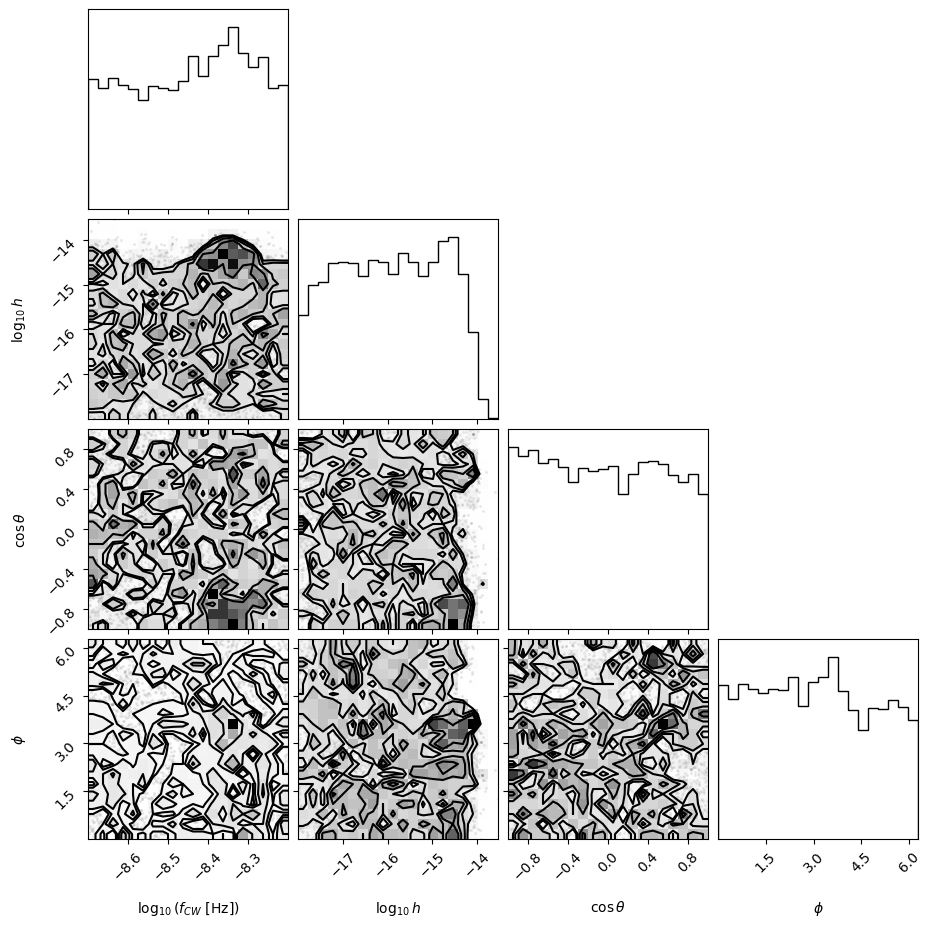

In [19]:
# show recovery of CW parameters

# there are 8 CW parameters we could plot
# to reduce the size of the corner plot let's only show a subset
param_ndxs_to_plot = np.r_[1, 4, 5, 6]

# parameter labels for plotting
cw_param_labels = np.array([r'$\log_{10}(\mathcal{M}\,\,[M_\odot])$',
                             r'$\log_{10}(f_{CW}\,\,[\text{Hz}])$',
                             r'$\cos{\iota}$', r'$\psi$', r'$\log_{10} h$',
                             r'$\cos{\theta}$', r'$\phi$', r'$\Phi_0$'])

# plot samples from Prometheus
fig = corner.corner(data=cw_samples[:, param_ndxs_to_plot],
                    labels=cw_param_labels[param_ndxs_to_plot],
                    # plot_contours=False,
                    # plot_density=False,
                    )

## Bonus content

### Initialization

The model we constructed above is high-dimensional (6174 dimensions to be exact!). By default, NumPyro initializes the sampler to a random point in parameter space - sometimes this isn't a problem, sometimes it is! In high-dimensions it's increasingly likely the sampler will warm-up in a *non-representative* region of parameter space or get stuck on a small local maximum, and as a result fail to explore the full posterior.

For some models (espicially complex models) it's helpful to initialize the sampler in a region close to the *maximum a posteriori*.

In [20]:
# print the names and shapes of parameters in our joint model
print(pta_model.get_param_names_and_shapes())

{'psr_params': (67, 30), 'gwb_params': (2,), 'cw_params': (8,), 'psr_phases': (67,), 'standard_psr_dists': (67,), 'z': (67, 60)}


We'll make a dictionary with some initial parameter values. It's important the initial parameter values are JAX arrays with the same shape as specified in the cell above. We don't need to initialize all the parameter values, just those we think would benefit the sampler. One option is to set the parameter values equal to the mean value from a previous run or a previous year's data set. 

Setting the standardized Fourier coefficients, $z$, to zero initially is often a good choice. This maximizes the posterior (conditioned on the values of the spectral parameters) and initializes thousands of dimensions. We'll also initialize the power in all frequencies in every pulsar to a conservative value. This is just to start the sampler, if the data supports it, the chain will migrate to another region of parameter space.

In [21]:
# dictionary with some initial parameter values
# unlisted parameters are initialized by NumPyro
init_dict = {'z': jnp.zeros((NG15_data.npsrs, 2 * NG15_data.nfreqs)),
             'psr_params': jnp.ones((NG15_data.npsrs, NG15_data.nfreqs)) * -15.}

# then we can start the sampler at these parameter values
from numpyro.infer.initialization import init_to_value
nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model,
                                 init_strategy=init_to_value(values=init_dict))

# and run in the usual way
# mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
#                           num_warmup=500,
#                           num_samples=5000)
# mcmc.run(jr.key(239238))
# samples = mcmc.get_samples()

## Parallel tempering

NumPyro's NUTS sampler doesn't include parallel tempering, but we can run independent chains at different temperatures. Then we can compute evidences / Bayes factors with thermodynamic integration.

In [22]:
# run at a temperature T > 1
# T = 10.0
# mcmc.run(jr.key(3829), T=T)
# samples = mcmc.get_samples()